In [1]:
import os
import requests

import matplotlib as mpl
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import statsmodels.stats.multitest as smm
from scipy.stats import mannwhitneyu
from itertools import combinations

mpl.rcParams['pdf.fonttype'] = 42
mpl.rcParams['ps.fonttype'] = 42

In [ ]:
#let's download and import the feature table directly from the FBMN job in GNPS2
task_id = '8be3e6be2924474db9f24be9252dbb54'
response = requests.get(f'https://gnps2.org/result?task={task_id}&viewname=quantificationdownload&resultdisplay_type=task')
directory_path = '/.../temp/'

#import the metadata
metadata = pd.read_csv('/.../Plusrise_Metadata.tsv', sep='\t')
column_interest = 'ATTRIBUTE_bmi.grp' #this is the column in the metadata table we will work with

with open(directory_path + task_id + '.csv', 'wb') as f:
    f.write(response.content)
    print(f"File saved at {directory_path}")
    
ftable = pd.read_csv(os.path.join(directory_path + task_id + '.csv'), sep=',')
#just keep the column relative to the samples and feature ids
ftable = ftable[[col for col in ftable.columns if col.endswith('Peak area') or col == 'row ID']]


In [3]:
prefix = "MS_"
# formatting table for box plots
ftable = ftable.T.reset_index()
ftable.columns = ftable.iloc[0]
ftable = ftable[1:].add_prefix(prefix).rename(columns={'MS_row ID': 'filename'})
ftable.head()

# remove .mzML/.mzXML patterns from metadata and ftable
metadata['filename'] = metadata['filename'].str.replace(r'\.(mzML|mzXML)$', '', regex=True)
ftable['filename'] = ftable['filename'].str.replace(r'\.(mzML|mzXML) Peak area$', '', regex=True)

# merge and reorganize
ftable_merged = pd.merge(
    ftable,
    metadata[['filename', column_interest]],
    on='filename',
    how='left'
)

ftable_merged.columns = [col.replace('.0', '') if col.endswith('.0') else col for col in ftable_merged.columns]
last_column = ftable_merged.iloc[:, -1]
ftable_merged = pd.concat([last_column, ftable_merged.iloc[:, :-1]], axis=1)

ftable_filtered_merged = ftable_merged[[column_interest, 'filename', 'MS_15833', 'MS_14027']]

# keep only rows where we have usable metadata
excluded_groups = {'Not available', 'PlateBlank', '6mix', 'QC_Pool', 'NA', 'Underweight'}
ftable_filtered_merged = ftable_filtered_merged[
    ~ftable_filtered_merged[column_interest].isin(excluded_groups)
].dropna(subset=[column_interest])

# remove outlier for the box plot
ftable_filtered_merged = ftable_filtered_merged[ftable_filtered_merged['filename'] != 'P3_F1_364172682']

library_matches = pd.DataFrame({
    'MS_#Scan#': ['MS_15833', 'MS_14027'],
    'Compound_Name_simplified': ['Carnitine-Dihydroferulic acid', 'Carnitine-Dihydroferulic acid-Sulfate']
})

## Mann-Whitney U - removing zeros

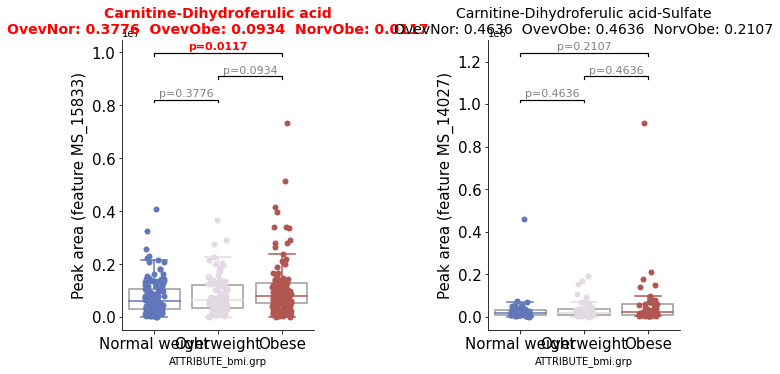

In [ ]:
def nonzero_group_values(data, group_col, feature_col, group_name):
    values = data.loc[data[group_col] == group_name, feature_col]
    return values[values > 0].dropna()

# reorganize the column order
ms_features = pd.DataFrame(ftable_filtered_merged.columns[2:], columns=['MS_#Scan#'])
ordered_feature_names = ms_features['MS_#Scan#'].tolist()

# Get group labels
group_labels = ftable_filtered_merged[column_interest].unique().tolist()
if len(group_labels) < 2:
    raise ValueError("column_interest must divide the data into at least two groups.")

# All pairwise combinations
pairs = list(combinations(group_labels, 2))

# Placeholder dictionary to hold p-values per feature per pair
p_values_pairs = {}  # {feature: {(g1, g2): p_val}}

for feature_name in ordered_feature_names:
    p_values_pairs[feature_name] = {}
    pair_pvals = []

    for (g1, g2) in pairs:
        d1 = nonzero_group_values(ftable_filtered_merged, column_interest, feature_name, g1)
        d2 = nonzero_group_values(ftable_filtered_merged, column_interest, feature_name, g2)

        # Skip if either group has fewer than 2 non-zero values
        if len(d1) < 2 or len(d2) < 2:
            pair_pvals.append(np.nan)
        else:
            _, p = mannwhitneyu(d1, d2, alternative='two-sided')
            pair_pvals.append(p)

    # FDR correction (exclude NaNs)
    valid_idx = [i for i, p in enumerate(pair_pvals) if not np.isnan(p)]
    if valid_idx:
        valid_pvals = [pair_pvals[i] for i in valid_idx]
        _, corrected, _, _ = smm.multipletests(valid_pvals, alpha=0.05, method='fdr_bh')
        for idx, corr_p in zip(valid_idx, corrected):
            pair_pvals[idx] = corr_p

    for key, pval in zip(pairs, pair_pvals):
        p_values_pairs[feature_name][key] = pval

# Plot
plt.figure(figsize=(50, 25))

unique_values = ["Normal weight", "Overweight", "Obese"]
ftable_filtered_merged[column_interest] = pd.Categorical(
    ftable_filtered_merged[column_interest], categories=unique_values, ordered=True
)

my_pal = sns.color_palette("twilight_shifted", len(unique_values))
color_dict = dict(zip(unique_values, my_pal))
color_dict_white = {key: 'white' for key in unique_values}
category_positions = {cat: i for i, cat in enumerate(unique_values)}

for i, feature_name in enumerate(ordered_feature_names, 1):
    title_name = library_matches.loc[
        library_matches['MS_#Scan#'] == feature_name,
        'Compound_Name_simplified'
    ].iloc[0]
    ax = plt.subplot(5, 10, i)

    data_nonzero = ftable_filtered_merged.copy()
    data_nonzero[feature_name] = data_nonzero[feature_name].where(data_nonzero[feature_name] > 0, np.nan)

    sns.boxplot(
        x=column_interest,
        y=feature_name,
        data=data_nonzero,
        notch=False,
        palette=color_dict_white,
        showfliers=False,
        ax=ax
    )

    # Set box edge colors using ax.patches
    for j, patch in enumerate(ax.patches):
        col = color_dict[unique_values[j % len(unique_values)]]
        patch.set_edgecolor(col)
        patch.set_linewidth(1.5)

    # Color whiskers, medians, and caps using ax.lines
    n_lines_per_box = len(ax.lines) // len(unique_values)
    for j, group in enumerate(unique_values):
        col = color_dict[group]
        start = j * n_lines_per_box
        end = start + n_lines_per_box
        for line in ax.lines[start:end]:
            line.set_color(col)
            line.set_mfc(col)
            line.set_mec(col)

    # Stripplot (non-zero values only)
    for group in unique_values:
        subset = data_nonzero[data_nonzero[column_interest] == group]
        sns.stripplot(
            x=column_interest,
            y=feature_name,
            data=subset,
            color=color_dict[group],
            jitter=0.15,
            size=6,
            ax=ax
        )

    # Draw significance brackets
    y_max = data_nonzero[feature_name].max()
    y_range = y_max - data_nonzero[feature_name].min()
    bracket_step = y_range * 0.12

    # Sort pairs by distance between groups (closer pairs drawn lower)
    sorted_pairs = sorted(pairs, key=lambda pair: abs(category_positions[pair[0]] - category_positions[pair[1]]))

    for level, (g1, g2) in enumerate(sorted_pairs):
        p = p_values_pairs[feature_name].get((g1, g2), np.nan)
        if np.isnan(p):
            continue

        x1 = category_positions[g1]
        x2 = category_positions[g2]
        y = y_max + bracket_step * (level + 1)

        ax.plot(
            [x1, x1, x2, x2],
            [y - bracket_step * 0.1, y, y, y - bracket_step * 0.1],
            lw=1.2,
            color='black'
        )

        p_text = f"p={p:.4f}"
        text_color = 'red' if p <= 0.05 else 'gray'
        ax.text(
            (x1 + x2) / 2,
            y + bracket_step * 0.05,
            p_text,
            ha='center',
            va='bottom',
            fontsize=11,
            color=text_color,
            fontweight='bold' if p <= 0.05 else 'normal'
        )

    # Title: red/bold if any pair is significant
    any_sig = any(p <= 0.05 for p in p_values_pairs[feature_name].values() if not np.isnan(p))
    title_color = 'red' if any_sig else 'black'
    title_weight = 'bold' if any_sig else 'normal'

    ax.set_ylabel(f'Peak area (feature {feature_name})', fontsize=15)
    ax.tick_params(axis='both', labelsize=15)

    # Show all pair p-values in subtitle
    pval_str = '  '.join([
        f"{g1[:3]}v{g2[:3]}: {p:.4f}" if not np.isnan(p) else f"{g1[:3]}v{g2[:3]}: n/a"
        for (g1, g2), p in p_values_pairs[feature_name].items()
    ])
    ax.set_title(f'{title_name}\n{pval_str}', fontsize=14, color=title_color, fontweight=title_weight)

plt.tight_layout()
plt.subplots_adjust(top=0.91)
sns.despine()
plt.savefig(f'/.../boxplot.pdf')
plt.show()